In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
#Configurar ambiente e carregtar a base
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_DIR = Path("/content/drive/MyDrive/portfolio/shopmais-churn-eda")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = PROJECT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta de imagens:", IMAGES_DIR)

df = pd.read_csv(PROCESSED_DIR / "shopmais_churn_features.csv")

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (5630, 36)


,customer_id,churn,tenure,preferred_login_device,city_tier,warehouse_to_home_km,preferred_payment_mode,gender,hours_spent_on_app,number_of_devices_registered,preferred_order_category,satisfaction_score,marital_status,number_of_address,complained,order_amount_hike_from_last_year,coupons_used,order_count,days_since_last_order,cashback_amount,tenure_was_missing,warehouse_to_home_km_was_missing,hours_spent_on_app_was_missing,order_amount_hike_from_last_year_was_missing,coupons_used_was_missing,order_count_was_missing,days_since_last_order_was_missing,tenure_group,recency_group,satisfaction_group,complaint_satisfaction_risk,coupon_intensity,cashback_per_order,engagement_score,warehouse_distance_group,risk_segment
0,50001,1,4.0000,Mobile Phone,3,6.0000,Debit Card,Female,3.0000,3,Laptop & Accessory,2,Single,9,1,11.0000,1.0000,1.0000,5.0000,159.9300,0,0,0,0,0,0,0,4-6 meses,0-7 dias,baixa satisfação,reclamou + baixa satisfação,1.0000,159.9300,1.0000,perto,insatisfeito crítico
1,50002,1,9.0000,Phone,1,8.0000,UPI,Male,3.0000,4,Mobile,3,Single,7,1,15.0000,0.0000,1.0000,0.0000,120.9000,1,0,0,0,0,0,0,7-12 meses,0-7 dias,satisfação neutra,reclamou + média/alta satisfação,0.0000,120.9000,1.2000,perto,demais clientes
2,50003,1,9.0000,Phone,1,30.0000,Debit Card,Male,2.0000,4,Mobile,3,Single,6,1,14.0000,0.0000,1.0000,3.0000,120.2800,1,0,0,0,0,0,0,7-12 meses,0-7 dias,satisfação neutra,reclamou + média/alta satisfação,0.0000,120.2800,1.0000,longe,demais clientes
3,50004,1,0.0000,Phone,3,15.0000,Debit Card,Male,2.0000,4,Laptop & Accessory,5,Single,8,0,23.0000,0.0000,1.0000,3.0000,134.0700,0,0,0,0,0,0,0,0-3 meses,0-7 dias,alta satisfação,não reclamou + média/alta satisfação,0.0000,134.0700,1.0000,médio,cliente novo
4,50005,1,0.0000,Phone,1,12.0000,CC,Male,3.0000,3,Mobile,5,Single,3,0,11.0000,1.0000,1.0000,3.0000,129.6000,0,0,1,0,0,0,0,0-3 meses,0-7 dias,alta satisfação,não reclamou + média/alta satisfação,1.0000,129.6000,1.0000,médio,cliente novo


# Modelo Preditivo de Churn

Nesta etapa, será desenvolvido um modelo de Machine Learning para prever a probabilidade de churn dos clientes da ShopMais.

O objetivo não é apenas obter uma métrica técnica, mas transformar o modelo em uma ferramenta de priorização para o negócio.

O modelo será usado para:

1. identificar clientes com maior risco de churn;
2. entender quais variáveis mais influenciam esse risco;
3. apoiar campanhas preventivas de retenção;
4. ranquear clientes para atuação do time de CRM.

In [4]:
# Separar variáveis preditoras e alvo
target_col = "churn"

id_cols = ["customer_id"]

# Evitamos usar colunas que já são agrupamentos ou regras manuais muito derivadas,
# para manter o modelo mais próximo das variáveis originais e evitar redundância excessiva.
cols_to_drop = [
    target_col,
    "customer_id",
    "risk_segment"
]

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df[target_col]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nDistribuição do target:")
display(y.value_counts(normalize=True).mul(100).rename("percentual"))

Dimensão de X: (5630, 33)
Dimensão de y: (5630,)

Distribuição do target:


,percentual
churn,
0,83.1616
1,16.8384


In [5]:
#Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nChurn no treino:")
display(y_train.value_counts(normalize=True).mul(100))

print("\nChurn no teste:")
display(y_test.value_counts(normalize=True).mul(100))

Treino: (4222, 33)
Teste: (1408, 33)

Churn no treino:


,proportion
churn,
0,83.1596
1,16.8404



Churn no teste:


,proportion
churn,
0,83.1676
1,16.8324


In [6]:
# Identificar colunas numéricas e categóricas
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Variáveis numéricas:", len(numeric_features))
print(numeric_features)

print("\nVariáveis categóricas:", len(categorical_features))
print(categorical_features)

Variáveis numéricas: 23
['tenure', 'city_tier', 'warehouse_to_home_km', 'hours_spent_on_app', 'number_of_devices_registered', 'satisfaction_score', 'number_of_address', 'complained', 'order_amount_hike_from_last_year', 'coupons_used', 'order_count', 'days_since_last_order', 'cashback_amount', 'tenure_was_missing', 'warehouse_to_home_km_was_missing', 'hours_spent_on_app_was_missing', 'order_amount_hike_from_last_year_was_missing', 'coupons_used_was_missing', 'order_count_was_missing', 'days_since_last_order_was_missing', 'coupon_intensity', 'cashback_per_order', 'engagement_score']

Variáveis categóricas: 10
['preferred_login_device', 'preferred_payment_mode', 'gender', 'preferred_order_category', 'marital_status', 'tenure_group', 'recency_group', 'satisfaction_group', 'complaint_satisfaction_risk', 'warehouse_distance_group']


In [8]:
#Criar pipeline de pré-processamento e modelo
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['preferred_login_device',
                                                   'preferred_payment_mode',
                                                   'gender',
                                                   'preferred_order_category',
                                                   'marital_status',
                                                   'tenure_group',
                                                   'recency_group',
                                                   'satisfaction_group',
                                                   'complaint_satisfaction_risk',
                                                   'warehouse_distance_group']),
                                                 ('numeric', 'passt...
                                                   'hours_spent_on_app_was_missing',
                                                   'order_amount_hike_from_last_year_was_missing',
                                                   'coupons_used_was_missing',
                                                   'order_count_was_missing',
                                                   'days_since_last_order_was_missing',
                                                   'coupon_intensity',
                                                   'cashback_per_order',
                                                   'engagement_score'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [9]:
# Treinar o modelo
clf.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [10]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, digits=4))

ROC AUC: 0.9223
Average Precision: 0.7199

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9612    0.8676    0.9120      1171
           1     0.5584    0.8270    0.6667       237

    accuracy                         0.8608      1408
   macro avg     0.7598    0.8473    0.7893      1408
weighted avg     0.8934    0.8608    0.8707      1408



## Métrica priorizada

Neste problema, recall da classe churn é mais importante do que accuracy isoladamente.

A empresa deseja identificar o maior número possível de clientes com risco de churn para agir preventivamente. Em termos de negócio, deixar de identificar um cliente que realmente vai abandonar a plataforma pode ser mais prejudicial do que abordar preventivamente um cliente que não abandonaria.

Por isso, a análise do modelo considera:

- recall da classe churn;
- precision da classe churn;
- ROC AUC;
- ranking de clientes por probabilidade de churn.

### Principais métricas

- ROC AUC: 0,9223
- Accuracy: 86,08%
- Recall para churn: 82,70%
- Precision para churn: 55,84%

Esses resultados indicam que o modelo consegue separar muito bem clientes com maior e menor risco de churn.

# Interpretação do recall

O recall mede a capacidade de detecção, para churn foi de 82,7%.

Isso significa que o modelo conseguiu identificar aproximadamente 83 em cada 100 clientes que realmente entraram em churn.

Essa métrica é extremamente importante para o negócio.

Em problemas de retenção, normalmente é mais grave deixar de identificar um cliente com risco de churn do que abordar preventivamente um cliente que talvez não abandonasse a plataforma.

Por esse motivo, recall é uma das métricas mais relevantes para o problema.

---

# Interpretação da precision

A precision mede a confiabilidade da predição e foi de 55,8%.

Isso significa que, entre os clientes classificados pelo modelo como churn, aproximadamente 56% realmente estavam em churn.

Embora existam falsos positivos, isso é aceitável em estratégias de retenção, pois o objetivo do modelo é ampliar a capacidade preventiva da empresa.

Na prática:

- é melhor abordar preventivamente alguns clientes que não abandonariam;
- do que deixar passar clientes que realmente irão churnar.

---
# interpretação da acurácia

A acurácia responde a pergunta: De um modo geral, o sistema acerta?  
Para esse modelo, significa que de um modo geral a classificação está acertando 86% das vezes.

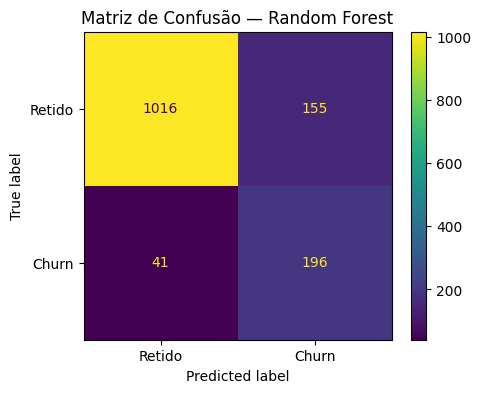

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retido", "Churn"]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Matriz de Confusão — Random Forest")
plt.show()

# Interpretação da matriz de confusão

## Resultados do modelo

- 1016 clientes foram corretamente classificados como retidos;
- 196 clientes foram corretamente classificados como churn;
- 155 clientes foram classificados como churn sem realmente churnar;
- apenas 41 clientes churn foram perdidos pelo modelo.

---

# O que isso significa para o negócio?

O modelo consegue capturar a maior parte dos clientes em risco antes do abandono.

Os 41 clientes que o modelo não conseguiu identificar representam os casos mais difíceis de prever, provavelmente associados a comportamentos menos claros ou eventos inesperados.

Já os 155 falsos positivos representam clientes que poderiam receber campanhas preventivas mesmo sem necessariamente abandonar a plataforma.

Do ponto de vista operacional, isso costuma ser aceitável em estratégias de CRM e retenção.

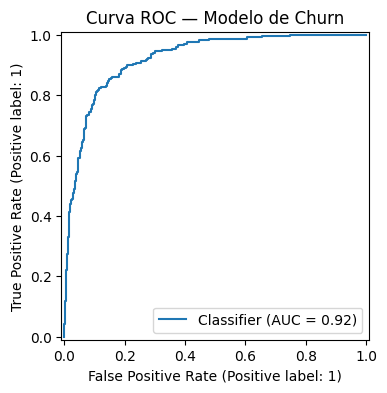

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.set_title("Curva ROC — Modelo de Churn")
plt.show()

# O que significa ROC AUC = 0,92?

A métrica ROC AUC mede a capacidade do modelo de diferenciar clientes que vão cancelar dos que vão permanecer.

O valor varia entre:

- 0,50 → modelo aleatório;
- 0,70 → modelo razoável;
- 0,80 → modelo forte;
- acima de 0,90 → modelo excelente.

Com ROC AUC de 0,92, o modelo da ShopMais apresenta excelente capacidade preditiva.

Na prática, isso significa que o modelo consegue identificar padrões comportamentais fortemente associados ao churn.

Quanto mais próxima a curva estiver do canto superior esquerdo do gráfico, melhor o modelo consegue diferenciar clientes em churn de clientes retidos.

O comportamento observado confirma que o modelo possui forte capacidade discriminatória.

In [13]:
# Ranking de clientes com risco de churn
test_results = X_test.copy()

test_results["customer_id"] = df.loc[X_test.index, "customer_id"]
test_results["actual_churn"] = y_test.values
test_results["churn_probability"] = y_proba

risk_ranking = (
    test_results[
        ["customer_id", "actual_churn", "churn_probability"]
    ]
    .sort_values("churn_probability", ascending=False)
    .reset_index(drop=True)
)

risk_ranking.head(20)

,customer_id,actual_churn,churn_probability
0,53402,1,0.9533
1,54618,1,0.9493
2,54288,1,0.9450
3,55500,1,0.9415
4,54870,1,0.9202
5,51215,1,0.9197
6,53751,1,0.9166
7,52077,1,0.9158
8,50607,1,0.9100
9,54023,1,0.9079


# Ranking de clientes por probabilidade de churn

Além de classificar clientes como churn ou não churn, o modelo também gera uma probabilidade individual de churn para cada cliente.

Essa probabilidade funciona como um score de risco.

Por exemplo, o primeiro, cliente com probabilidade de churn de 0,9533, possui risco estimado de 95% de abandonar a plataforma, segundo os padrões aprendidos pelo modelo.

Esse ranking é útil porque permite que a empresa priorize ações de retenção. Em vez de abordar todos os clientes da mesma forma, o time de CRM pode começar pelos clientes com maior probabilidade de churn.

## Aplicação prática

A ShopMais poderia usar o ranking da seguinte forma:

- clientes com maior probabilidade de churn entram primeiro em campanhas preventivas;
- clientes de alto risco recebem ofertas ou contatos personalizados;
- clientes com risco médio entram em campanhas automáticas;
- clientes de baixo risco seguem em ações normais de relacionamento.

Esse tipo de ranking transforma o modelo em uma ferramenta operacional, não apenas em uma análise estatística.

In [14]:
# Faixa de risco
risk_ranking["risk_band"] = pd.cut(
    risk_ranking["churn_probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["baixo risco", "médio risco", "alto risco"],
    include_lowest=True
)

risk_band_summary = (
    risk_ranking
    .groupby("risk_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churned=("actual_churn", "sum"),
        avg_probability=("churn_probability", "mean"),
        churn_rate=("actual_churn", "mean")
    )
    .reset_index()
)

risk_band_summary["churn_rate_pct"] = risk_band_summary["churn_rate"] * 100
risk_band_summary["avg_probability_pct"] = risk_band_summary["avg_probability"] * 100

risk_band_summary

,risk_band,customers,churned,avg_probability,churn_rate,churn_rate_pct,avg_probability_pct
0,baixo risco,832,13,0.1711,0.0156,1.5625,17.1084
1,médio risco,299,48,0.4277,0.1605,16.0535,42.7738
2,alto risco,277,176,0.7493,0.6354,63.5379,74.9330


# Interpretação das faixas de risco

O modelo foi utilizado para dividir clientes em três grupos:

- baixo risco;
- médio risco;
- alto risco.

## Resultados encontrados

### Baixo risco
- churn real: 1,6%

### Médio risco
- churn real: 16,1%

### Alto risco
- churn real: 63,5%

---

# O que isso significa?

O modelo conseguiu criar uma segmentação extremamente útil para o negócio.

Clientes classificados como alto risco apresentaram churn real de 63,5%, muito acima da média geral da base.

Isso significa que o modelo pode ser utilizado operacionalmente para priorizar clientes em campanhas preventivas.

---

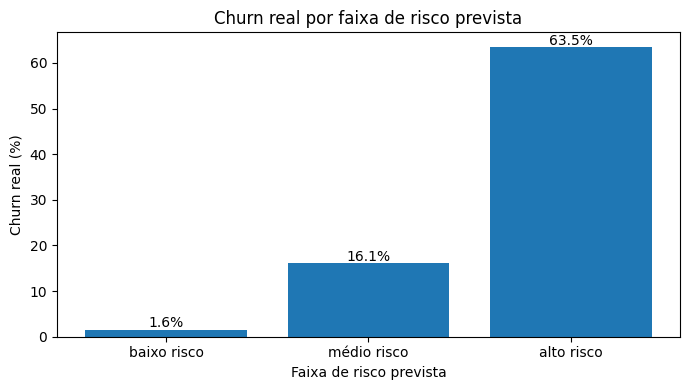

In [15]:
plot_data = risk_band_summary.copy()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    plot_data["risk_band"].astype(str),
    plot_data["churn_rate_pct"]
)

ax.set_title("Churn real por faixa de risco prevista")
ax.set_xlabel("Faixa de risco prevista")
ax.set_ylabel("Churn real (%)")

for index, value in enumerate(plot_data["churn_rate_pct"]):
    ax.text(index, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [16]:
# Feature importance
trained_model = clf.named_steps["model"]
trained_preprocessor = clf.named_steps["preprocessor"]

feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
40,numeric__tenure,0.2376
21,categorical__tenure_group_0-3 meses,0.1514
36,categorical__complaint_satisfaction_risk_recla...,0.0618
52,numeric__cashback_amount,0.0560
47,numeric__complained,0.0474
51,numeric__days_since_last_order,0.0379
22,categorical__tenure_group_13-24 meses,0.0299
61,numeric__cashback_per_order,0.0288
20,categorical__marital_status_Single,0.0240
46,numeric__number_of_address,0.0205


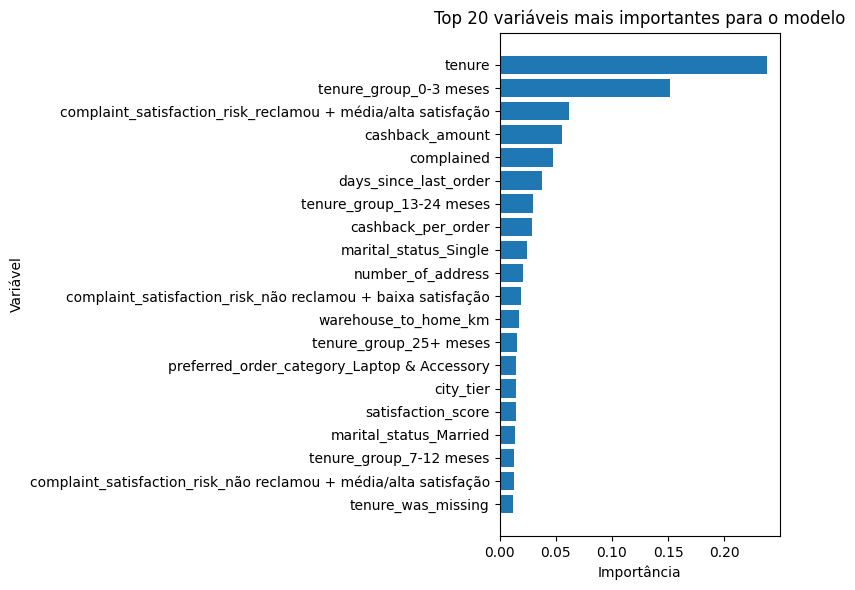

,feature_clean,importance
40,tenure,0.2376
21,tenure_group_0-3 meses,0.1514
36,complaint_satisfaction_risk_reclamou + média/a...,0.0618
52,cashback_amount,0.0560
47,complained,0.0474
51,days_since_last_order,0.0379
22,tenure_group_13-24 meses,0.0299
61,cashback_per_order,0.0288
20,marital_status_Single,0.0240
46,number_of_address,0.0205


In [17]:
importance_df["feature_clean"] = (
    importance_df["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
)

top_features = importance_df.head(20).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top_features["feature_clean"][::-1],
    top_features["importance"][::-1]
)

ax.set_title("Top 20 variáveis mais importantes para o modelo")
ax.set_xlabel("Importância")
ax.set_ylabel("Variável")

plt.tight_layout()
plt.show()

top_features[["feature_clean", "importance"]]

# Variáveis mais importantes para prever churn

O modelo identificou que as variáveis mais relevantes foram:

1. tenure
2. clientes com até 3 meses
3. reclamação combinada com satisfação
4. cashback
5. existência de reclamação
6. dias desde o último pedido

---

# O que isso significa na prática?

## 1. Tempo de relacionamento é o principal fator

A variável mais importante foi tenure, ou seja, o tempo de relacionamento do cliente com a empresa.

Isso confirma os resultados encontrados na análise exploratória:

clientes novos possuem risco muito maior de churn.

---

## 2. Reclamações possuem forte impacto

Variáveis relacionadas a reclamação apareceram entre as mais importantes do modelo.

Isso mostra que clientes que passaram por problemas ou atritos possuem maior probabilidade de abandonar a plataforma.

---

## 3. Recência de compra influencia fortemente o churn

Clientes há muito tempo sem comprar também apresentam maior risco.

Isso reforça a importância de campanhas de reativação.

---

## 4. Cashback e incentivos financeiros possuem influência relevante

O cashback apareceu entre as variáveis importantes, indicando que benefícios financeiros podem influenciar retenção e comportamento de compra.

---

In [18]:
risk_ranking_path = REPORTS_DIR / "churn_risk_ranking.csv"
feature_importance_path = REPORTS_DIR / "feature_importance.csv"
risk_band_summary_path = REPORTS_DIR / "risk_band_summary.csv"

risk_ranking.to_csv(risk_ranking_path, index=False, encoding="utf-8")
importance_df.to_csv(feature_importance_path, index=False, encoding="utf-8")
risk_band_summary.to_csv(risk_band_summary_path, index=False, encoding="utf-8")

print("Arquivos salvos:")
print(risk_ranking_path)
print(feature_importance_path)
print(risk_band_summary_path)

Arquivos salvos:
/content/drive/MyDrive/portfolio/shopmais-churn-eda/reports/churn_risk_ranking.csv
/content/drive/MyDrive/portfolio/shopmais-churn-eda/reports/feature_importance.csv
/content/drive/MyDrive/portfolio/shopmais-churn-eda/reports/risk_band_summary.csv


In [19]:
# Estimativa simples de impacto financeiro

average_customer_value = 250

high_risk_customers = risk_ranking[risk_ranking["risk_band"] == "alto risco"].shape[0]

estimated_revenue_at_risk = high_risk_customers * average_customer_value

print("Clientes em alto risco:", high_risk_customers)
print(f"Ticket médio estimado por cliente: R$ {average_customer_value:,.2f}")
print(f"Receita estimada em risco: R$ {estimated_revenue_at_risk:,.2f}")

Clientes em alto risco: 277
Ticket médio estimado por cliente: R$ 250.00
Receita estimada em risco: R$ 69,250.00


# Estimativa de impacto financeiro

Para transformar o modelo em uma análise de negócio, foi criada uma estimativa simples de receita em risco.

Como a base não possui uma variável direta de receita total por cliente, foi adotado um ticket médio hipotético de R$ 250 por cliente.

A fórmula utilizada foi:

Receita em risco = número de clientes em alto risco × ticket médio estimado

Essa estimativa não deve ser interpretada como valor contábil exato, mas como uma aproximação para apoiar priorização de negócio.

## Por que isso é útil?

A estimativa de impacto financeiro ajuda a responder uma pergunta prática:

“Quanto dinheiro pode estar em risco se a empresa não agir sobre os clientes com maior probabilidade de churn?”

Esse raciocínio torna a análise mais próxima de uma decisão empresarial real.

In [20]:
# Impacto financeiro por faixa de risco

average_customer_value = 250

financial_impact = risk_band_summary.copy()

financial_impact["estimated_revenue_at_risk"] = (
    financial_impact["customers"] *
    financial_impact["churn_rate"] *
    average_customer_value
)

financial_impact["estimated_revenue_at_risk"] = financial_impact["estimated_revenue_at_risk"].round(2)

financial_impact

,risk_band,customers,churned,avg_probability,churn_rate,churn_rate_pct,avg_probability_pct,estimated_revenue_at_risk
0,baixo risco,832,13,0.1711,0.0156,1.5625,17.1084,"3,250.0000"
1,médio risco,299,48,0.4277,0.1605,16.0535,42.7738,"12,000.0000"
2,alto risco,277,176,0.7493,0.6354,63.5379,74.9330,"44,000.0000"


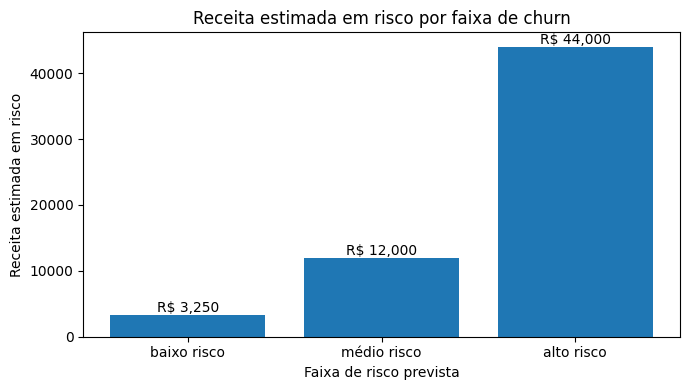

In [21]:
plot_data = financial_impact.copy()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    plot_data["risk_band"].astype(str),
    plot_data["estimated_revenue_at_risk"]
)

ax.set_title("Receita estimada em risco por faixa de churn")
ax.set_xlabel("Faixa de risco prevista")
ax.set_ylabel("Receita estimada em risco")

for index, value in enumerate(plot_data["estimated_revenue_at_risk"]):
    ax.text(index, value, f"R$ {value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Impacto financeiro por faixa de risco

A tabela de impacto financeiro estima a receita em risco dentro de cada faixa de risco prevista pelo modelo.

Diferente da estimativa simples anterior, aqui o cálculo considera:

- quantidade de clientes em cada faixa;
- churn real observado naquela faixa;
- ticket médio estimado por cliente.

A fórmula utilizada foi:

Receita em risco estimada = clientes da faixa × churn real da faixa × ticket médio

Essa abordagem permite comparar quais grupos concentram maior perda potencial.

Mesmo que a faixa de alto risco tenha menos clientes do que a base total, ela pode concentrar uma parcela relevante da receita em risco por apresentar churn real muito superior.

# Conclusão final do modelo

O modelo confirmou as principais hipóteses levantadas na análise exploratória.

Os principais fatores associados ao churn foram:

- pouco tempo de relacionamento;
- reclamações;
- baixa recorrência de compra;
- inatividade recente;
- comportamento de engajamento.

Além disso, o modelo apresentou capacidade preditiva suficiente para uso prático em estratégias de CRM e retenção.

A principal conclusão do projeto é que o churn da ShopMais parece estar fortemente concentrado na ativação inicial do cliente, e não distribuído igualmente em toda a base.

# Conclusão sobre ranking e impacto financeiro

O ranking de probabilidade de churn permite transformar o modelo em uma ferramenta prática de priorização.

Em vez de aplicar campanhas genéricas para toda a base, a empresa pode concentrar recursos nos clientes com maior risco estimado.

A análise por faixa de risco mostrou que clientes classificados como alto risco possuem churn real muito superior aos demais grupos. Isso indica que o modelo consegue separar clientes prioritários de forma eficiente.

Ao adicionar uma estimativa de receita em risco, o projeto deixa de ser apenas uma análise técnica e passa a apoiar uma decisão de negócio: onde a empresa deve investir primeiro para reduzir perdas.

Essa abordagem conecta Machine Learning, CRM e impacto financeiro.